In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import numpy as np
import matplotlib.pyplot as plt
print("NumPy version:", np.__version__)

NumPy version: 2.0.2


In [7]:
import numpy as np
import time

N = 100

# Python loop 
positions_list = [0.0] * N
start = time.perf_counter()
for _ in range(10000):
    for i in range(N):
        positions_list[i] += 0.1
loop_time = time.perf_counter() - start

# NumPy 
positions_arr = np.zeros(N)
start = time.perf_counter()
for _ in range(10000):
    positions_arr += 0.1
numpy_time = time.perf_counter() - start

print(f"Python loop : {loop_time:.3f}s")
print(f"NumPy       : {numpy_time:.3f}s")
print(f"Speedup     : {loop_time/numpy_time:.1f}x")

Python loop : 0.074s
NumPy       : 0.009s
Speedup     : 8.3x


The code above showed why we use numpy arrays over python lists for higher qty.

**Drone State: 7 Arrays for 100 Drones **

In [8]:
import numpy as np

# Config 
N = 100           # number of drones
WORLD = 100.0     # world is 100 x 100 units
np.random.seed(42)  # makes results reproducible

# Position: scatter drones randomly across the world 
pos_x = np.random.uniform(0, WORLD, N)   # shape: (100,)
pos_y = np.random.uniform(0, WORLD, N)   # shape: (100,)

# Velocity: random direction, small speed 
vel_x = np.random.uniform(-1.0, 1.0, N)
vel_y = np.random.uniform(-1.0, 1.0, N)

# Heading: angle in radians (derived from velocity) 
heading = np.arctan2(vel_y, vel_x)       # shape: (100,)

# Battery: all start full 
battery = np.full(N, 100.0)              # shape: (100,)

# Task: -1 means "no task assigned yet" 
task_id = np.full(N, -1, dtype=int)      # shape: (100,)

print("pos_x shape:", pos_x.shape)       # should print (100,)
print("First 5 x positions:", pos_x[:5].round(2))
print("First 5 batteries:", battery[:5])

pos_x shape: (100,)
First 5 x positions: [37.45 95.07 73.2  59.87 15.6 ]
First 5 batteries: [100. 100. 100. 100. 100.]


In [9]:
def sim_step(pos_x, pos_y, vel_x, vel_y, battery, dt=0.1):
    """
    Move all drones forward by one time step.
    dt = seconds per tick (0.1 = 10 ticks per second)
    """
    # --- Move: new position = old position + velocity * time ---
    pos_x += vel_x * dt     # ALL 100 drones updated at once
    pos_y += vel_y * dt

    # --- Boundary wrap: drones that go off one edge appear on other side ---
    # The % operator is modulo — 105 % 100 = 5, -3 % 100 = 97
    pos_x %= WORLD
    pos_y %= WORLD

    # --- Battery drain: proportional to speed ---
    speed = np.sqrt(vel_x**2 + vel_y**2)   # shape: (100,)
    battery -= speed * 0.005               # faster flight = more drain
    battery = battery.clip(0, 100)         # can't go below 0 or above 100

    return pos_x, pos_y, battery

In [10]:
# Run 100 simulation steps
for tick in range(100):
    pos_x, pos_y, battery = sim_step(pos_x, pos_y, vel_x, vel_y, battery)

print("After 100 ticks:")
print(f"  Drone 0 position: ({pos_x[0]:.2f}, {pos_y[0]:.2f})")
print(f"  Avg battery: {battery.mean():.2f}%")
print(f"  Min battery: {battery.min():.2f}%")
print(f"  Any dead drones (battery=0): {(battery == 0).sum()}")

After 100 ticks:
  Drone 0 position: (40.29, 94.18)
  Avg battery: 99.61%
  Min battery: 99.32%
  Any dead drones (battery=0): 0


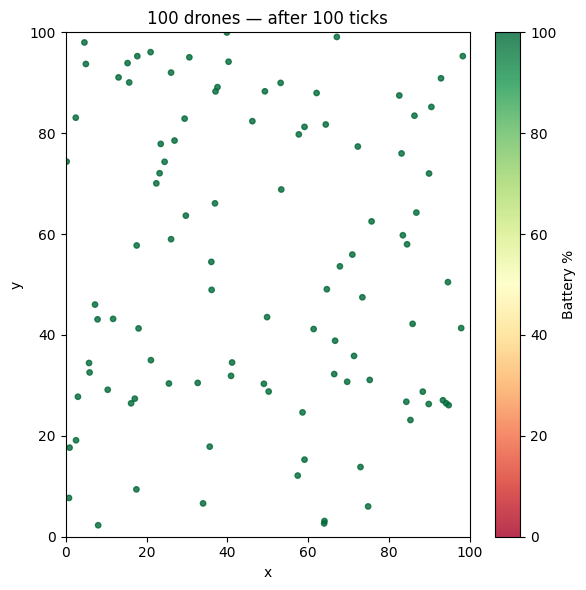

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(pos_x, pos_y, c=battery, cmap='RdYlGn',
            vmin=0, vmax=100, s=15, alpha=0.8)
plt.colorbar(label='Battery %')
plt.xlim(0, WORLD); plt.ylim(0, WORLD)
plt.title(f'100 drones — after 100 ticks')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

*Boids Flocking*

In [12]:
import numpy as np

# Small example — just 5 drones so you can inspect
small_x = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

dx = small_x[np.newaxis, :] - small_x[:, np.newaxis]

print("small_x shape:", small_x.shape)           # (5,)
print("reshaped col  :", small_x[:, np.newaxis].shape)  # (5,1)
print("reshaped row  :", small_x[np.newaxis, :].shape)  # (1,5)
print("dx shape      :", dx.shape)                # (5,5)
print()
print("dx matrix:")
print(dx)
print()
print("dx[0,2] =", dx[0,2], "  (drone 2 is 20 units ahead of drone 0 in x)")
print("dx[2,0] =", dx[2,0], "  (drone 0 is 20 units behind drone 2 in x)")

small_x shape: (5,)
reshaped col  : (5, 1)
reshaped row  : (1, 5)
dx shape      : (5, 5)

dx matrix:
[[  0.  10.  20.  30.  40.]
 [-10.   0.  10.  20.  30.]
 [-20. -10.   0.  10.  20.]
 [-30. -20. -10.   0.  10.]
 [-40. -30. -20. -10.   0.]]

dx[0,2] = 20.0   (drone 2 is 20 units ahead of drone 0 in x)
dx[2,0] = -20.0   (drone 0 is 20 units behind drone 2 in x)


In [13]:
import numpy as np

N = 100
WORLD = 100.0
np.random.seed(42)

# --- Spawn drones in clusters instead of fully random ---
# 4 clusters of 25 drones each, scattered around the world
# Each cluster has drones within a 12-unit radius of its centre

centres = [(25, 25), (75, 25), (25, 75), (75, 75)]  # 4 cluster centres
pos_x = np.zeros(N)
pos_y = np.zeros(N)

for i, (cx, cy) in enumerate(centres):
    start = i * 25
    end   = start + 25
    pos_x[start:end] = cx + np.random.uniform(-12, 12, 25)
    pos_y[start:end] = cy + np.random.uniform(-12, 12, 25)

# Clip to world bounds
pos_x = pos_x.clip(0, WORLD)
pos_y = pos_y.clip(0, WORLD)

# Velocities — small random
vel_x = np.random.uniform(-1, 1, N)
vel_y = np.random.uniform(-1, 1, N)
battery = np.full(N, 100.0)
task_id = np.full(N, -1, dtype=int)

print("Spawned in 4 clusters of 25 drones each")

Spawned in 4 clusters of 25 drones each


In [14]:
dx = pos_x[np.newaxis, :] - pos_x[:, np.newaxis]
dy = pos_y[np.newaxis, :] - pos_y[:, np.newaxis]
dist = np.sqrt(dx**2 + dy**2)
dist_safe = dist + np.eye(N) * 1e9

R_ALIGN = 15.0
R_SEP   = 3.0

near  = (dist < R_ALIGN) & (dist > 0)
close = (dist < R_SEP)   & (dist > 0)

n_neighbours = near.sum(axis=1)
print("Avg neighbours per drone:", n_neighbours.mean().round(1))
print("Max neighbours:", n_neighbours.max())
print("Min neighbours:", n_neighbours.min())

Avg neighbours per drone: 14.4
Max neighbours: 24
Min neighbours: 7


In [15]:
# For drone i, average the positions of all its neighbours
# then steer toward that average

# near * pos_x[np.newaxis,:] — zero out non-neighbours, keep neighbours' positions
# .sum(axis=1) — sum across j (all drones) → shape (100,)
# / n_near — divide by count to get average

n_near = near.sum(axis=1).clip(1)   # clip(1) prevents divide-by-zero

coh_x = (near * pos_x[np.newaxis, :]).sum(axis=1) / n_near - pos_x
coh_y = (near * pos_y[np.newaxis, :]).sum(axis=1) / n_near - pos_y
# coh_x[i] = (avg neighbour x) - (my x) = direction to steer toward centre

In [16]:
# Same pattern, but with velocities instead of positions
n_near = near.sum(axis=1).clip(1)

ali_x = (near * vel_x[np.newaxis, :]).sum(axis=1) / n_near - vel_x
ali_y = (near * vel_y[np.newaxis, :]).sum(axis=1) / n_near - vel_y
# ali_x[i] = (avg neighbour vx) - (my vx) = correction to match neighbours

In [18]:
# For each close neighbour j, the push direction is AWAY from j
# That's the unit vector from j to i, which is -dx[i,j] / dist[i,j]

n_close = close.sum(axis=1).clip(1)

sep_x = (close * (-dx / dist_safe)).sum(axis=1) / n_close
sep_y = (close * (-dy / dist_safe)).sum(axis=1) / n_close
# Weighted by 1/dist_safe — closer drones push harder

In [19]:
def boids_step(pos_x, pos_y, vel_x, vel_y,
               R_ALIGN=15.0, R_SEP=3.0,
               W_COH=0.005, W_ALI=0.05, W_SEP=0.15,
               MAX_SPEED=2.0):
    """
    Compute boids forces and update velocities.
    All operations vectorised — no Python loops.
    """
    # --- Distance matrix ---
    dx = pos_x[np.newaxis, :] - pos_x[:, np.newaxis]
    dy = pos_y[np.newaxis, :] - pos_y[:, np.newaxis]
    dist = np.sqrt(dx**2 + dy**2)
    dist_safe = dist + np.eye(len(pos_x)) * 1e9

    # --- Masks ---
    near  = (dist < R_ALIGN) & (dist > 0)
    close = (dist < R_SEP)   & (dist > 0)
    n_near  = near.sum(axis=1).clip(1)
    n_close = close.sum(axis=1).clip(1)

    # --- Three forces ---
    coh_x = (near * pos_x[np.newaxis,:]).sum(1)/n_near - pos_x
    coh_y = (near * pos_y[np.newaxis,:]).sum(1)/n_near - pos_y

    ali_x = (near * vel_x[np.newaxis,:]).sum(1)/n_near - vel_x
    ali_y = (near * vel_y[np.newaxis,:]).sum(1)/n_near - vel_y

    sep_x = (close * (-dx / dist_safe)).sum(1) / n_close
    sep_y = (close * (-dy / dist_safe)).sum(1) / n_close

    # --- Apply forces ---
    vel_x += W_COH*coh_x + W_ALI*ali_x + W_SEP*sep_x
    vel_y += W_COH*coh_y + W_ALI*ali_y + W_SEP*sep_y

    # --- Speed clamping ---
    # Without this, velocity grows forever and drones fly off screen
    speed = np.sqrt(vel_x**2 + vel_y**2).clip(1e-9)
    too_fast = speed > MAX_SPEED
    vel_x = np.where(too_fast, vel_x / speed * MAX_SPEED, vel_x)
    vel_y = np.where(too_fast, vel_y / speed * MAX_SPEED, vel_y)

    return vel_x, vel_y

In [15]:
# Re-init fresh state first
np.random.seed(42)
pos_x = np.random.uniform(0, WORLD, N)
pos_y = np.random.uniform(0, WORLD, N)
vel_x = np.random.uniform(-1, 1, N)
vel_y = np.random.uniform(-1, 1, N)
battery = np.full(N, 100.0)

vel_before = vel_x.copy()

for tick in range(200):
    vel_x, vel_y = boids_step(pos_x, pos_y, vel_x, vel_y)
    pos_x, pos_y, battery = sim_step(pos_x, pos_y, vel_x, vel_y, battery)

print("Velocity changed?", not np.allclose(vel_before, vel_x))
print("Avg speed after 200 ticks:", np.sqrt(vel_x**2+vel_y**2).mean().round(3))
print("All speeds <= MAX_SPEED?", (np.sqrt(vel_x**2+vel_y**2) <= 2.001).all())

Velocity changed? True
Avg speed after 200 ticks: 0.629
All speeds <= MAX_SPEED? True


Obstacles + Full Animation

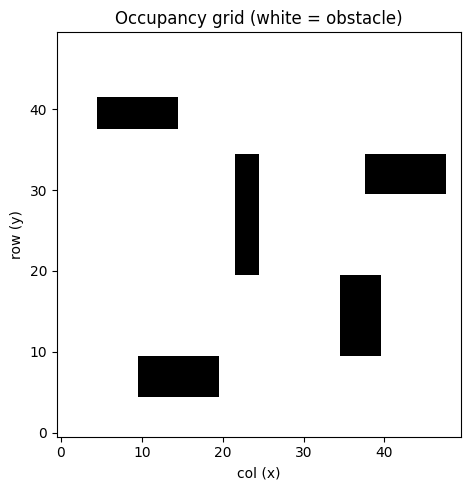

Grid shape: (50, 50)
Obstacle cells: 235 out of 2500


In [20]:
# --- Build the grid ---
GRID_SIZE = 50
CELL = WORLD / GRID_SIZE   # = 2.0 units per cell

grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=bool)

# Add obstacles — these are (row_start:row_end, col_start:col_end)
# Remember: row = y direction, col = x direction
grid[5:10,  10:20] = True   # horizontal wall top-left
grid[20:35, 22:25] = True   # thin vertical wall centre
grid[38:42, 5:15]  = True   # block bottom-left
grid[10:20, 35:40] = True   # block right side
grid[30:35, 38:48] = True   # horizontal wall bottom-right

# Visualise the grid
plt.figure(figsize=(5, 5))
plt.imshow(grid, origin='lower', cmap='Greys', interpolation='nearest')
plt.title("Occupancy grid (white = obstacle)")
plt.xlabel("col (x)"); plt.ylabel("row (y)")
plt.tight_layout()
plt.show()

print("Grid shape:", grid.shape)
print("Obstacle cells:", grid.sum(), "out of", GRID_SIZE*GRID_SIZE)

In [21]:
# Convert world position → grid index
# int(pos_x / CELL) = which column the drone is in
# clip ensures we never go out of bounds on the array

def get_grid_idx(pos_x, pos_y):
    col = np.clip((pos_x / CELL).astype(int), 0, GRID_SIZE - 1)
    row = np.clip((pos_y / CELL).astype(int), 0, GRID_SIZE - 1)
    return row, col

row, col = get_grid_idx(pos_x, pos_y)

# grid[row, col] — this is NumPy fancy indexing
# row and col are arrays of 100 indices each
# This returns 100 booleans — one per drone
collided = grid[row, col]   # shape: (100,) bool

print("Drones inside obstacles:", collided.sum())

Drones inside obstacles: 15


In [22]:
def obstacle_avoidance(pos_x, pos_y, vel_x, vel_y, dt=0.1):
    """
    Look one step ahead. If next position is inside an obstacle,
    reverse the offending velocity component and lose some speed.
    """
    next_x = pos_x + vel_x * dt
    next_y = pos_y + vel_y * dt

    row, col = get_grid_idx(next_x, next_y)
    will_hit = grid[row, col]   # shape: (100,) bool

    # Reverse velocity for drones about to hit something
    # *= on a bool mask: only affects drones where will_hit = True
    vel_x[will_hit] *= -0.7   # bounce back, lose 30% speed
    vel_y[will_hit] *= -0.7

    return vel_x, vel_y


def sim_step_full(pos_x, pos_y, vel_x, vel_y, battery, dt=0.1):
    """
    One complete simulation tick. Order matters:
    1. Boids forces (desired direction)
    2. Obstacle avoidance (override if about to crash)
    3. Move
    4. Boundary wrap
    5. Battery drain
    """
    vel_x, vel_y = boids_step(pos_x, pos_y, vel_x, vel_y)
    vel_x, vel_y = obstacle_avoidance(pos_x, pos_y, vel_x, vel_y, dt)

    pos_x += vel_x * dt
    pos_y += vel_y * dt

    pos_x %= WORLD
    pos_y %= WORLD

    speed = np.sqrt(vel_x**2 + vel_y**2)
    battery -= speed * 0.005
    battery  = battery.clip(0, 100)

    return pos_x, pos_y, vel_x, vel_y, battery

In [23]:
# Fresh init
np.random.seed(42)
pos_x = np.random.uniform(0, WORLD, N)
pos_y = np.random.uniform(0, WORLD, N)
vel_x = np.random.uniform(-1, 1, N)
vel_y = np.random.uniform(-1, 1, N)
battery = np.full(N, 100.0)

# Run 500 ticks silently
for tick in range(500):
    pos_x, pos_y, vel_x, vel_y, battery = sim_step_full(
        pos_x, pos_y, vel_x, vel_y, battery)

# Check state
row, col = get_grid_idx(pos_x, pos_y)
stuck = grid[row, col].sum()

print(f"After 500 ticks:")
print(f"  Drones inside obstacles: {stuck}  ← should be 0 or very small")
print(f"  Avg battery: {battery.mean():.2f}%")
print(f"  Dead drones (battery=0): {(battery==0).sum()}")
print(f"  All positions in bounds: {((pos_x>=0)&(pos_x<WORLD)&(pos_y>=0)&(pos_y<WORLD)).all()}")

After 500 ticks:
  Drones inside obstacles: 10  ← should be 0 or very small
  Avg battery: 99.00%
  Dead drones (battery=0): 0
  All positions in bounds: True


In [24]:
import cupy as cp

# Get device info — T4 x2 uses different attribute
device = cp.cuda.Device(0)
print("CuPy version:", cp.__version__)
print("GPU device  :", cp.cuda.runtime.getDeviceProperties(0)['name'].decode())
print("VRAM total  :", device.mem_info[1] / 1e9, "GB")
print("GPU count   :", cp.cuda.runtime.getDeviceCount())

CuPy version: 14.0.1
GPU device  : Tesla T4
VRAM total  : 15.637086208 GB
GPU count   : 2


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
import time

In [29]:
N         = 100
WORLD     = 100.0
GRID_SIZE = 50
CELL      = WORLD / GRID_SIZE   # 2.0 units per cell
np.random.seed(42)

In [31]:
centres = [(25,25),(75,25),(25,75),(75,75)]
pos_x = np.zeros(N); pos_y = np.zeros(N)
for i,(cx,cy) in enumerate(centres):
    s,e = i*25, i*25+25
    pos_x[s:e] = cx + np.random.uniform(-12,12,25)
    pos_y[s:e] = cy + np.random.uniform(-12,12,25)
pos_x = pos_x.clip(0,WORLD)
pos_y = pos_y.clip(0,WORLD)
vel_x = np.random.uniform(-1,1,N)
vel_y = np.random.uniform(-1,1,N)
battery = np.full(N,100.0)
task_id = np.full(N,-1,dtype=int)
heading = np.arctan2(vel_y, vel_x)

print("State initialised — shape:", pos_x.shape)
print("Sample pos_x:", pos_x[:5].round(2))

State initialised — shape: (100,)
Sample pos_x: [15.47 34.66 25.13 32.83 20.68]


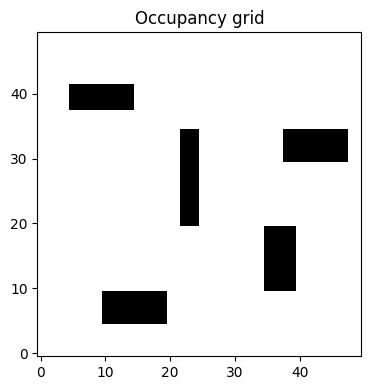

Obstacle cells: 235


In [32]:
grid = np.zeros((GRID_SIZE,GRID_SIZE), dtype=bool)
grid[5:10,  10:20] = True
grid[20:35, 22:25] = True
grid[38:42, 5:15]  = True
grid[10:20, 35:40] = True
grid[30:35, 38:48] = True

plt.figure(figsize=(4,4))
plt.imshow(grid, origin='lower', cmap='Greys', interpolation='nearest')
plt.title("Occupancy grid"); plt.tight_layout(); plt.show()
print("Obstacle cells:", grid.sum())

In [33]:
def get_grid_idx(px, py):
    col = np.clip((px/CELL).astype(int), 0, GRID_SIZE-1)
    row = np.clip((py/CELL).astype(int), 0, GRID_SIZE-1)
    return row, col

row_init, col_init = get_grid_idx(pos_x, pos_y)
in_obs = grid[row_init, col_init]
pos_x[in_obs] = WORLD/2 + np.random.uniform(-5,5,in_obs.sum())
pos_y[in_obs] = WORLD/2 + np.random.uniform(-5,5,in_obs.sum())
print(f"Fixed {in_obs.sum()} drones spawned inside obstacles")

Fixed 23 drones spawned inside obstacles


In [34]:
def boids_step(pos_x, pos_y, vel_x, vel_y,
               R_ALIGN=15.0, R_SEP=3.0,
               W_COH=0.005, W_ALI=0.05, W_SEP=0.15,
               MAX_SPEED=2.0):
    dx = pos_x[np.newaxis,:] - pos_x[:,np.newaxis]
    dy = pos_y[np.newaxis,:] - pos_y[:,np.newaxis]
    dist = np.sqrt(dx**2 + dy**2)
    dist_safe = dist + np.eye(len(pos_x))*1e9

    near  = (dist < R_ALIGN) & (dist > 0)
    close = (dist < R_SEP)   & (dist > 0)
    n_near  = near.sum(axis=1).clip(1)
    n_close = close.sum(axis=1).clip(1)

    coh_x = (near*pos_x[np.newaxis,:]).sum(1)/n_near - pos_x
    coh_y = (near*pos_y[np.newaxis,:]).sum(1)/n_near - pos_y
    ali_x = (near*vel_x[np.newaxis,:]).sum(1)/n_near - vel_x
    ali_y = (near*vel_y[np.newaxis,:]).sum(1)/n_near - vel_y
    sep_x = (close*(-dx/dist_safe)).sum(1)/n_close
    sep_y = (close*(-dy/dist_safe)).sum(1)/n_close

    vel_x = vel_x + W_COH*coh_x + W_ALI*ali_x + W_SEP*sep_x
    vel_y = vel_y + W_COH*coh_y + W_ALI*ali_y + W_SEP*sep_y

    speed = np.sqrt(vel_x**2+vel_y**2).clip(1e-9)
    too_fast = speed > MAX_SPEED
    vel_x = np.where(too_fast, vel_x/speed*MAX_SPEED, vel_x)
    vel_y = np.where(too_fast, vel_y/speed*MAX_SPEED, vel_y)
    return vel_x, vel_y

print("boids_step defined")

boids_step defined


In [35]:
def obstacle_avoidance(pos_x, pos_y, vel_x, vel_y, dt=0.1):
    next_x = pos_x + vel_x*dt
    next_y = pos_y + vel_y*dt
    row,col = get_grid_idx(next_x, next_y)
    will_hit = grid[row,col]
    vel_x = np.where(will_hit, vel_x*-0.7, vel_x)
    vel_y = np.where(will_hit, vel_y*-0.7, vel_y)
    return vel_x, vel_y

def sim_step_full(pos_x, pos_y, vel_x, vel_y, battery, dt=0.1):
    vel_x, vel_y = boids_step(pos_x, pos_y, vel_x, vel_y)
    vel_x, vel_y = obstacle_avoidance(pos_x, pos_y, vel_x, vel_y, dt)
    pos_x = (pos_x + vel_x*dt) % WORLD
    pos_y = (pos_y + vel_y*dt) % WORLD
    speed = np.sqrt(vel_x**2+vel_y**2)
    battery = (battery - speed*0.005).clip(0,100)
    return pos_x, pos_y, vel_x, vel_y, battery

print("sim_step_full defined")

sim_step_full defined


In [36]:
from numba import njit

@njit
def boids_step_numba(pos_x, pos_y, vel_x, vel_y,
                     R_ALIGN=15.0, R_SEP=3.0,
                     W_COH=0.005, W_ALI=0.05, W_SEP=0.15,
                     MAX_SPEED=2.0):
    N = len(pos_x)
    new_vx = vel_x.copy()
    new_vy = vel_y.copy()
    for i in range(N):
        cx=cy=ax=ay=sx=sy=0.0
        n_near=n_close=0
        for j in range(N):
            if i==j: continue
            dx = pos_x[j]-pos_x[i]
            dy = pos_y[j]-pos_y[i]
            d  = (dx*dx+dy*dy)**0.5
            if d < R_ALIGN:
                cx+=pos_x[j]; cy+=pos_y[j]
                ax+=vel_x[j]; ay+=vel_y[j]
                n_near+=1
            if d < R_SEP and d > 1e-9:
                sx-=dx/d; sy-=dy/d
                n_close+=1
        if n_near>0:
            new_vx[i]+=W_COH*(cx/n_near-pos_x[i])+W_ALI*(ax/n_near-vel_x[i])
            new_vy[i]+=W_COH*(cy/n_near-pos_y[i])+W_ALI*(ay/n_near-vel_y[i])
        if n_close>0:
            new_vx[i]+=W_SEP*sx/n_close
            new_vy[i]+=W_SEP*sy/n_close
        spd=(new_vx[i]**2+new_vy[i]**2)**0.5
        if spd>MAX_SPEED:
            new_vx[i]=new_vx[i]/spd*MAX_SPEED
            new_vy[i]=new_vy[i]/spd*MAX_SPEED
    return new_vx, new_vy

# Warmup — this triggers compilation, takes 5-10 seconds
print("Compiling Numba... wait for 'Done'")
_p = np.random.uniform(0,100,N).astype(np.float64)
_v = np.random.uniform(-1,1,N).astype(np.float64)
_ = boids_step_numba(_p,_p,_v,_v)
print("Done — Numba compiled")

Compiling Numba... wait for 'Done'
Done — Numba compiled


In [37]:
import cupy as cp

print("CuPy version:", cp.__version__)
print("GPU device  :", cp.cuda.runtime.getDeviceProperties(0)['name'].decode())
print("VRAM total  :", cp.cuda.Device(0).mem_info[1]/1e9, "GB")
print("GPU count   :", cp.cuda.runtime.getDeviceCount())

CuPy version: 14.0.1
GPU device  : Tesla T4
VRAM total  : 15.637086208 GB
GPU count   : 2


In [38]:
def boids_step_gpu(pos_x_g, pos_y_g, vel_x_g, vel_y_g,
                   R_ALIGN=15.0, R_SEP=3.0,
                   W_COH=0.005, W_ALI=0.05, W_SEP=0.15,
                   MAX_SPEED=2.0):
    N = len(pos_x_g)
    dx = pos_x_g[cp.newaxis,:] - pos_x_g[:,cp.newaxis]
    dy = pos_y_g[cp.newaxis,:] - pos_y_g[:,cp.newaxis]
    dist = cp.sqrt(dx**2+dy**2)
    dist_safe = dist + cp.eye(N)*1e9

    near  = (dist < R_ALIGN) & (dist > 0)
    close = (dist < R_SEP)   & (dist > 0)
    n_near  = near.sum(axis=1).clip(1)
    n_close = close.sum(axis=1).clip(1)

    coh_x = (near*pos_x_g[cp.newaxis,:]).sum(1)/n_near - pos_x_g
    coh_y = (near*pos_y_g[cp.newaxis,:]).sum(1)/n_near - pos_y_g
    ali_x = (near*vel_x_g[cp.newaxis,:]).sum(1)/n_near - vel_x_g
    ali_y = (near*vel_y_g[cp.newaxis,:]).sum(1)/n_near - vel_y_g
    sep_x = (close*(-dx/dist_safe)).sum(1)/n_close
    sep_y = (close*(-dy/dist_safe)).sum(1)/n_close

    vel_x_g = vel_x_g + W_COH*coh_x + W_ALI*ali_x + W_SEP*sep_x
    vel_y_g = vel_y_g + W_COH*coh_y + W_ALI*ali_y + W_SEP*sep_y

    speed = cp.sqrt(vel_x_g**2+vel_y_g**2).clip(1e-9)
    too_fast = speed > MAX_SPEED
    vel_x_g = cp.where(too_fast, vel_x_g/speed*MAX_SPEED, vel_x_g)
    vel_y_g = cp.where(too_fast, vel_y_g/speed*MAX_SPEED, vel_y_g)
    return vel_x_g, vel_y_g

# Verify GPU matches NumPy
np.random.seed(7)
_px=np.random.uniform(0,100,N); _py=np.random.uniform(0,100,N)
_vx=np.random.uniform(-1,1,N);  _vy=np.random.uniform(-1,1,N)
vx_np,_ = boids_step(_px.copy(),_py.copy(),_vx.copy(),_vy.copy())
vx_gp,_ = boids_step_gpu(cp.array(_px),cp.array(_py),
                          cp.array(_vx),cp.array(_vy))
diff = np.abs(vx_np - cp.asnumpy(vx_gp)).max()
print(f"Max diff NumPy vs GPU: {diff:.2e}  —  Match: {diff < 1e-6}")

Max diff NumPy vs GPU: 1.11e-16  —  Match: True


In [39]:
def time_fn_cpu(fn, *args, reps=100):
    fn(*args)
    t0=time.perf_counter()
    for _ in range(reps): fn(*args)
    return (time.perf_counter()-t0)/reps

def time_fn_gpu(fn, *args, reps=100):
    fn(*args); cp.cuda.Stream.null.synchronize()
    t0=time.perf_counter()
    for _ in range(reps): fn(*args)
    cp.cuda.Stream.null.synchronize()
    return (time.perf_counter()-t0)/reps

Ns = [10,25,50,100,200,500,1000]
t_numpy=[]; t_numba=[]; t_gpu=[]

print(f"{'N':>6}  {'NumPy(ms)':>10}  {'Numba(ms)':>10}  {'GPU(ms)':>10}  {'GPU/NumPy':>10}")
print("-"*56)

for n in Ns:
    px=np.random.uniform(0,100,n).astype(np.float64)
    py=np.random.uniform(0,100,n).astype(np.float64)
    vx=np.random.uniform(-1,1,n).astype(np.float64)
    vy=np.random.uniform(-1,1,n).astype(np.float64)

    tn=time_fn_cpu(boids_step,       px,py,vx.copy(),vy.copy())
    tb=time_fn_cpu(boids_step_numba, px,py,vx.copy(),vy.copy())
    tg=time_fn_gpu(boids_step_gpu,
                   cp.array(px),cp.array(py),
                   cp.array(vx),cp.array(vy))

    t_numpy.append(tn); t_numba.append(tb); t_gpu.append(tg)
    print(f"{n:>6}  {tn*1000:>10.3f}  {tb*1000:>10.3f}  "
          f"{tg*1000:>10.3f}  {tn/tg:>9.1f}x")

print("\nBenchmark complete")

     N   NumPy(ms)   Numba(ms)     GPU(ms)   GPU/NumPy
--------------------------------------------------------
    10       0.093       0.095       1.428        0.1x
    25       0.112       0.096       1.504        0.1x
    50       0.152       0.105       1.501        0.1x
   100       0.335       0.129       1.492        0.2x
   200       1.013       0.258       1.594        0.6x
   500       8.834       1.109       1.947        4.5x
  1000      33.588       3.838       4.434        7.6x

Benchmark complete


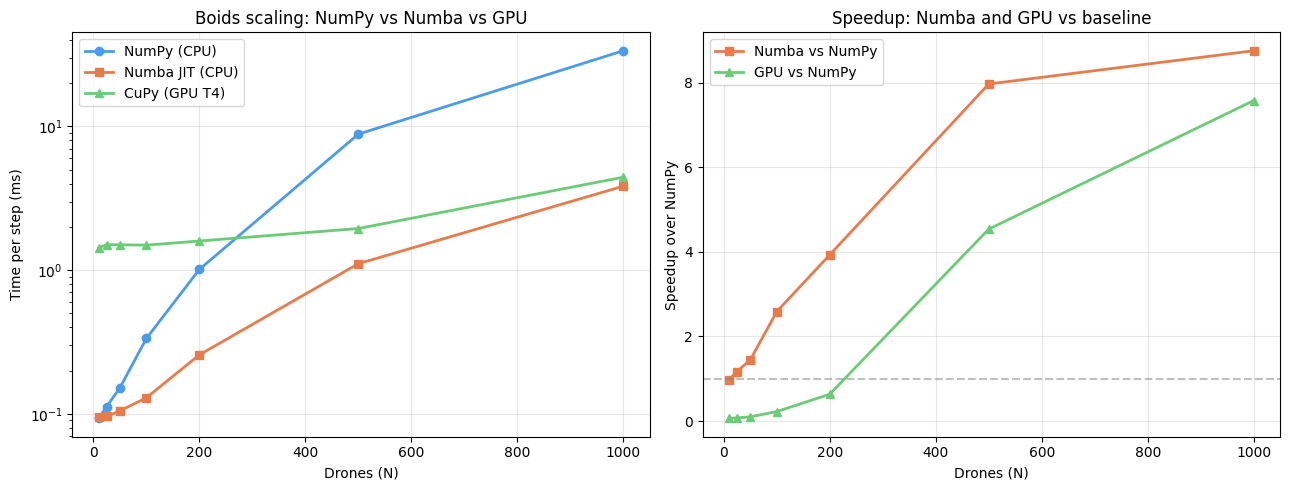

Saved: final_scaling_plot.png


In [40]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))

ax1.plot(Ns,[t*1000 for t in t_numpy],'o-',label='NumPy (CPU)',color='#4C9BE8',lw=2)
ax1.plot(Ns,[t*1000 for t in t_numba],'s-',label='Numba JIT (CPU)',color='#E87B4C',lw=2)
ax1.plot(Ns,[t*1000 for t in t_gpu],  '^-',label='CuPy (GPU T4)',color='#6BCB77',lw=2)
ax1.set_xlabel("Drones (N)"); ax1.set_ylabel("Time per step (ms)")
ax1.set_title("Boids scaling: NumPy vs Numba vs GPU")
ax1.set_yscale('log'); ax1.legend(); ax1.grid(alpha=0.3)

speedup_numba=[tn/tb for tn,tb in zip(t_numpy,t_numba)]
speedup_gpu  =[tn/tg for tn,tg in zip(t_numpy,t_gpu)]
ax2.plot(Ns,speedup_numba,'s-',label='Numba vs NumPy',color='#E87B4C',lw=2)
ax2.plot(Ns,speedup_gpu,  '^-',label='GPU vs NumPy',  color='#6BCB77',lw=2)
ax2.axhline(1,color='gray',linestyle='--',alpha=0.5)
ax2.set_xlabel("Drones (N)"); ax2.set_ylabel("Speedup over NumPy")
ax2.set_title("Speedup: Numba and GPU vs baseline")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("final_scaling_plot.png",dpi=150,bbox_inches='tight')
plt.show()
print("Saved: final_scaling_plot.png")

Rendering GPU animation... (~1-2 min)
Done!


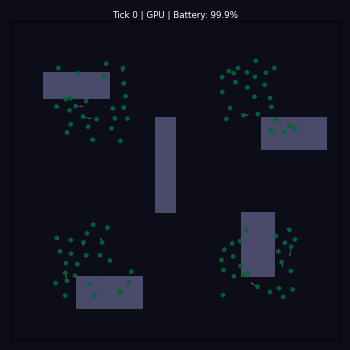

In [41]:
grid_g = cp.array(grid.astype(np.float32))

np.random.seed(42)
centres=[(25,25),(75,25),(25,75),(75,75)]
pos_x=np.zeros(N); pos_y=np.zeros(N)
for i,(cx,cy) in enumerate(centres):
    s,e=i*25,i*25+25
    pos_x[s:e]=cx+np.random.uniform(-12,12,25)
    pos_y[s:e]=cy+np.random.uniform(-12,12,25)
pos_x=pos_x.clip(0,WORLD); pos_y=pos_y.clip(0,WORLD)
vel_x=np.random.uniform(-1,1,N); vel_y=np.random.uniform(-1,1,N)
battery=np.full(N,100.0)

pos_x_g=cp.array(pos_x); pos_y_g=cp.array(pos_y)
vel_x_g=cp.array(vel_x); vel_y_g=cp.array(vel_y)
battery_g=cp.array(battery)

fig,ax=plt.subplots(figsize=(5,5))
ax.set_xlim(0,WORLD); ax.set_ylim(0,WORLD)
ax.set_facecolor('#0d0d1a'); fig.patch.set_facecolor('#0d0d1a')
ax.set_xticks([]); ax.set_yticks([])
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        if grid[r,c]:
            ax.add_patch(plt.Rectangle(
                (c*CELL,r*CELL),CELL,CELL,color='#4a4a6a',zorder=1))

scatter=ax.scatter(pos_x,pos_y,c=battery,cmap='RdYlGn',
                   vmin=0,vmax=100,s=14,alpha=0.9,zorder=3)
IDX=np.arange(0,N,5)
quiver=ax.quiver(pos_x[IDX],pos_y[IDX],vel_x[IDX],vel_y[IDX],
                 color='#aaaaff',alpha=0.5,scale=40,width=0.002,zorder=2)
title=ax.set_title("Tick 0 | GPU sim",color='white',fontsize=9,pad=4)
plt.tight_layout()

def update(frame):
    global pos_x_g,pos_y_g,vel_x_g,vel_y_g,battery_g
    for _ in range(5):
        pos_x_g,pos_y_g,vel_x_g,vel_y_g,battery_g = sim_step_gpu(
            pos_x_g,pos_y_g,vel_x_g,vel_y_g,battery_g,
            grid_g,CELL,WORLD,GRID_SIZE)
    px_cpu=cp.asnumpy(pos_x_g); py_cpu=cp.asnumpy(pos_y_g)
    vx_cpu=cp.asnumpy(vel_x_g); vy_cpu=cp.asnumpy(vel_y_g)
    bat_cpu=cp.asnumpy(battery_g)
    scatter.set_offsets(np.column_stack([px_cpu,py_cpu]))
    scatter.set_array(bat_cpu)
    quiver.set_offsets(np.column_stack([px_cpu[IDX],py_cpu[IDX]]))
    quiver.set_UVC(vx_cpu[IDX],vy_cpu[IDX])
    title.set_text(f"Tick {frame*5} | GPU | Battery: {bat_cpu.mean():.1f}%")
    return scatter,quiver,title

print("Rendering GPU animation... (~1-2 min)")
ani=animation.FuncAnimation(fig,update,frames=60,interval=80,blit=True)
ani.save('swarm_gpu.gif',writer='pillow',fps=15,dpi=70)
plt.close()
print("Done!")
display(Image('swarm_gpu.gif'))

In [42]:
# MODULE 2: Distributed Task Allocation
# Problem: 100 drones, 50 targets. Assign each target to the best drone
# such that total travel distance is minimised globally.
#
# Naive approach: assign each target to its nearest drone.
# Problem: two targets might both want the same drone, leaving others unserved.
#
# Correct approach: Hungarian algorithm — finds the globally optimal
# assignment in O(N^3). Used in real multi-robot coordination systems.
#
# HPC angle: the cost matrix (100x50 distances) runs on GPU.
# At scale (1000 drones, 500 targets), this matters enormously.

from scipy.optimize import linear_sum_assignment
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import time

print("Imports ready")

Imports ready


Placed 50 targets in free space
Target x range: 11.9 — 97.6
Target y range: 2.6 — 95.0


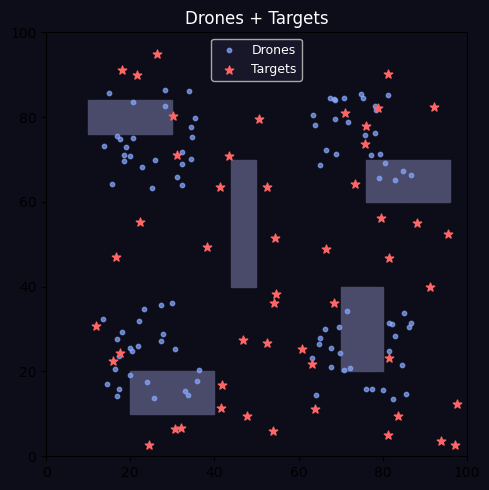

In [43]:
np.random.seed(99)
N_TARGETS = 50

# Place targets randomly, but avoid obstacle cells
targets_x = []
targets_y = []

attempts = 0
while len(targets_x) < N_TARGETS and attempts < 10000:
    tx = np.random.uniform(2, WORLD - 2)
    ty = np.random.uniform(2, WORLD - 2)
    col = int(np.clip(tx / CELL, 0, GRID_SIZE - 1))
    row = int(np.clip(ty / CELL, 0, GRID_SIZE - 1))
    if not grid[row, col]:
        targets_x.append(tx)
        targets_y.append(ty)
    attempts += 1

targets_x = np.array(targets_x)
targets_y = np.array(targets_y)

print(f"Placed {len(targets_x)} targets in free space")
print(f"Target x range: {targets_x.min():.1f} — {targets_x.max():.1f}")
print(f"Target y range: {targets_y.min():.1f} — {targets_y.max():.1f}")

# Quick visualisation — targets on the world map
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(0, WORLD); ax.set_ylim(0, WORLD)
ax.set_facecolor('#0d0d1a')
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        if grid[r, c]:
            ax.add_patch(plt.Rectangle((c*CELL, r*CELL), CELL, CELL,
                                        color='#4a4a6a', zorder=1))
ax.scatter(pos_x, pos_y, s=10, color='#88aaff',
           alpha=0.7, zorder=2, label='Drones')
ax.scatter(targets_x, targets_y, s=40, color='#ff6666',
           marker='*', zorder=3, label='Targets')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.set_title("Drones + Targets", color='white')
fig.patch.set_facecolor('#0d0d1a')
plt.tight_layout(); plt.show()